# Load metrics files for each version of a given experiment, and summarize performance in various tables

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from functools import reduce
import ast
import numpy as np
import pyvista as pv
import json
from pathlib import Path
from utils.metrics import estimate_typical_distance
from config import METRICS_DIR, PATIENT_MESHES_DIR, IMAGES_DIR

In [ ]:
# sometimes I saved single metrics (like LDDMM) as [value], so I need to have it as single value ...
def parse_value(x):
    # numpy array or list from LDDMM
    if isinstance(x, (np.ndarray, list, tuple)):
        return float(x[0])
    if isinstance(x, str):
        return float(ast.literal_eval(x)[0])
    # scalar from chamfer or haussdorff
    return float(x)

# for styling tables
def highlight_overall_best(val, mask):
    return 'background-color: orange' if mask else ''

def highlight_top3(val, rank):
    if rank == 1:
        return 'background-color: orange'
    elif rank == 2:
        return 'background-color: gray'
    elif rank == 3:
        return 'background-color: peru'  # bronze-ish color
    else:
        return ''
    
def style_table_top3_per_column(use_table, display_table):
    # Extract only mean values for comparison
    table_means = use_table.xs('mean', axis=1, level=1)
    # Best lambda_reg per column (per organ)
    best_mask = table_means.eq(table_means.min(axis=0), axis=1)
    # Rank the values per column (ascending because lower is better)
    ranks = table_means.rank(method='min', axis=0)  # smallest = rank 1

    table_styled = display_table.style.apply(
        lambda row: [
            highlight_top3(v, ranks.loc[row.name, col])
            for col, v in zip(table_means.columns, row)
        ],
        axis=1
    )

    return table_styled

def style_table_overall_best(use_table, display_table):
    # Extract only mean values for comparison
    table_means = use_table.xs('mean', axis=1, level=1)
    # Find the absolute minimum across the whole table
    overall_min = table_means.min().min()
    # Boolean mask where True indicates the overall best value
    best_mask = table_means == overall_min
    # Apply styling
    table_styled = display_table.style.apply(
        lambda row: [
            highlight_overall_best(v, best_mask.loc[row.name, col])
            for col, v in zip(table_means.columns, row)
        ],
        axis=1
    )
  
    return table_styled

def combine_table(table):

    table_combined = pd.DataFrame(index=table.index)

    for organ in table.columns.levels[0]:
        mean_col = (organ, 'mean')
        std_col = (organ, 'std')
        
        # Format as "mean ± std"
        table_combined[organ] = (
            table[mean_col].round(4).astype(str) + " ± " + table[std_col].round(4).astype(str)
        )

    return table_combined

def get_tables_meanstd_per_organ(df, index):

    table = (
        df
        .pivot_table(
            index=index, # ["lipschitz_lays", "code_reg"],   # can accept multi-index rows ["column label 1", "column label 2"] or single ones
            columns="organ",
            values=["mean", "std"],
            aggfunc="mean"
        )
        .sort_index()
        .swaplevel(axis=1)
        .sort_index(axis=1)
    )

    table_combined = combine_table(table)

    return table, table_combined

def get_tables_meanstd_overall(df, index, columns):


    table = (
        df
        .pivot_table(
            index=index,   # can accept multi-index rows ["column label 1", "column label 2"]
            columns=columns,
            values=["mean", "std"],
            aggfunc="mean"
        )
        .sort_index()
        .swaplevel(axis=1) # swaps organ and aggfunc, so instead of having "mean" and "std" as top level and then epi la ra for each, It's the other way around
        .sort_index(axis=1)
    )

    table_combined = combine_table(table)

    return table, table_combined


In [ ]:
def rescale_emtrics(df):
    scale_lddmm_for_display = 100.0

    patients = df["patient"].unique()
    organs = df["organ"].unique()
    rows = [] 
    for patient in patients: 
        for organ in organs:
            # retrieve carachteristic scale per patient, per organ, from original mesh, in the same scale in which I computed METRICS !!
            mesh_orig = pv.read(PATIENT_MESHES_DIR / patient / f"{organ}-processed.vtp")

            # ---- original scale, micrometers ---- #
            scale = mesh_orig.field_data["scale-tooriginalrange"][0]

            scale_millimeters = float(scale) * 0.001  # µm → mm

            # mesh_orig.points *= scale_millimeters

            # typical_mesh_distance = estimate_typical_distance(mesh_orig) # around 400 - 500 for meshes in micrometers, 0.400 - 0.500 for mesh in millimeters ...
            
            rows.append(
                {
                    "patient": patient,
                    "organ": organ,
                    "scaling": scale_millimeters
                }
            )

    df_scale_len = pd.DataFrame(rows)

    df_all_chd = df.query(" metric == 'chamfer' ").drop(columns="metric")
    df_all_hsd = df.query(" metric == 'haussdorff' ").drop(columns="metric")
    df_all_lddmm = df.query(" metric == 'LDDMM' ").drop(columns="metric")

    df_all_chd = df_all_chd.merge(df_scale_len, on=["patient", "organ"], how="left")
    df_all_hsd = df_all_hsd.merge(df_scale_len, on=["patient", "organ"], how="left")

    # both chamfer and haussdorf are LINEAR in distance from how I compute them, LDDMM is already computed in the scale I want since I can't rescale it after...
    df_all_chd["value_scaled"] = df_all_chd["value"] * df_all_chd["scaling"]
    df_all_hsd["value_scaled"] = df_all_hsd["value"] * df_all_hsd["scaling"]
    df_all_lddmm["value_scaled"] = df_all_lddmm["value"] * scale_lddmm_for_display

    return df_all_chd, df_all_hsd, df_all_lddmm


In [ ]:
experiment_name = "BatchSizeEffectCorrected"
exp_subdir = ""
which_shapes = "train"
CURRENT_EXP_DIR = METRICS_DIR / experiment_name

In [ ]:
# for these experiments, names are just like {version}-{experiment_name}-{metric}-{opt}.parquet
# retrieve all the wanted files
dfs = []

for file_path in list( CURRENT_EXP_DIR.glob(f"{experiment_name}*{which_shapes}.csv") ):
    df = pd.read_csv(file_path)

    # go fetch the specs file to add columns I need to differentiate versions
    version = file_path.stem.split("-")[1].split("_")[-1]    
    
    df["version"] = int(version)

    with open(f"experiments/{experiment_name}/version_{version}/hparams.json") as f:
        specs = json.load(f)

    # this has to be changed manually for what is wanted ...
    # df["lipschitz_lays"] = str( specs["Network_specs"]["lipschitz_layers"] )
    # df["alpha"] = specs["lipschitz_alpha"]
    # df["code_reg"] = specs["code_reg_lambda"]
    df["batch"] = specs["batch_size"]
    df["num_steps"] = int( specs["NumEpochs"] * np.floor( 89 / specs["batch_size"] ) )
    # anneal = specs["anneal_reg_loss"]
    # df["anneal"] = anneal 
    # df["act"] = specs["Network_specs"]["activation"]
    # df["latent"] = specs["Network_specs"]["latent_size"]
    
    dfs.append(df)

add_column_1 = "batch"
add_column_2 = "num_steps"

df_all = pd.concat(dfs, ignore_index=True)

df_all["value"] = df_all["value"].apply(parse_value)

df_all

# Rescale metrics 
Values of all metrics are computed on the meshes at their standardized scale. Chamfer and Haussdorff can easily be rescaled to any wanted physical scale. LDDMM can be rescaled just for display reason, since too small values look 0 practically ...

Additionally, for now I have used meshes in training standardized to REMOVE relative dimension! So I just manually bring meshes to their real scale, also reintroducing clearly relative size, but I have to note that the real network output is not modelling this information. So it may perform "the same" on shapes with different dimension because in reality they were reconstructed at the same scale, but it does not mean the network is capable of discerning relative volume, in fact, it cannot be since I didn't give it this information during training. **This is just to have the metrics value in a physical scale rather than adimensional and very small since standardized meshes are at unit scale**

In [ ]:
scale_lddmm_for_display = 100.0

patients = df_all["patient"].unique()
organs = df_all["organ"].unique()
rows = [] 
for patient in patients: 
    for organ in organs:
        # retrieve carachteristic scale per patient, per organ, from original mesh, in the same scale in which I computed METRICS !!
        mesh_orig = pv.read(PATIENT_MESHES_DIR / patient / f"{organ}-processed.vtp")

        # ---- original scale, micrometers ---- #
        scale = mesh_orig.field_data["scale-tooriginalrange"][0]

        scale_millimeters = float(scale) * 0.001  # µm → mm

        # mesh_orig.points *= scale_millimeters

        # typical_mesh_distance = estimate_typical_distance(mesh_orig) # around 400 - 500 for meshes in micrometers, 0.400 - 0.500 for mesh in millimeters ...
        
        rows.append(
            {
                "patient": patient,
                "organ": organ,
                "scaling": scale_millimeters
            }
        )

df_scale_len = pd.DataFrame(rows)

df_all_chd = df_all.query(" metric == 'chamfer' ").drop(columns="metric")
df_all_hsd = df_all.query(" metric == 'haussdorff' ").drop(columns="metric")
df_all_lddmm = df_all.query(" metric == 'LDDMM' ").drop(columns="metric")

df_all_chd = df_all_chd.merge(df_scale_len, on=["patient", "organ"], how="left")
df_all_hsd = df_all_hsd.merge(df_scale_len, on=["patient", "organ"], how="left")

# both chamfer and haussdorf are LINEAR in distance from how I compute them, LDDMM is already computed in the scale I want since I can't rescale it after...
df_all_chd["value_scaled"] = df_all_chd["value"] * df_all_chd["scaling"]
df_all_hsd["value_scaled"] = df_all_hsd["value"] * df_all_hsd["scaling"]
df_all_lddmm["value_scaled"] = df_all_lddmm["value"] * scale_lddmm_for_display

## Compute mean and std over all patients for each version and for each organ

In [ ]:
groupby_keep = ["organ", add_column_1, add_column_2]

df_chd = df_all_chd.groupby(groupby_keep)["value_scaled"].agg( 
    mean="mean",
    std="std"
).reset_index()

df_hsd = df_all_hsd.groupby(groupby_keep)["value_scaled"].agg( 
    mean="mean",
    std="std"
).reset_index()

df_lddmm = df_all_lddmm.groupby(groupby_keep)["value_scaled"].agg( 
    mean="mean",
    std="std"
).reset_index()

### Style into a table, highlight best values

In [ ]:
df = df_chd
table, table_combined = get_tables_meanstd_per_organ(df, index = [add_column_1, add_column_2])
table_styled = style_table_top3_per_column(table, table_combined)
print(f"Chamfer on {which_shapes}")
table_styled

In [ ]:
df = df_hsd
table, table_combined = get_tables_meanstd_per_organ(df, index = [add_column_1, add_column_2])
table_styled = style_table_top3_per_column(table, table_combined)
print(f"Haussdorff on {which_shapes}")
table_styled

In [ ]:
df = df_lddmm
table, table_combined = get_tables_meanstd_per_organ(df, index = [add_column_1, add_column_2])
table_styled = style_table_top3_per_column(table, table_combined)
print(f"LDDMM on {which_shapes}")
table_styled

## Groups also over all organs per patient

In [ ]:
groupby_keep = [add_column_1, add_column_2]

df_chd = df_all_chd.groupby(groupby_keep)["value_scaled"].agg( 
    mean="mean",
    std="std"
).reset_index()

df_hsd = df_all_hsd.groupby(groupby_keep)["value_scaled"].agg( 
    mean="mean",
    std="std"
).reset_index()

df_lddmm = df_all_lddmm.groupby(groupby_keep)["value_scaled"].agg( 
    mean="mean",
    std="std"
).reset_index()

In [ ]:
df = df_chd
table, table_combined = get_tables_meanstd_overall(df, index = add_column_1, columns = add_column_2)
table_styled = style_table_overall_best(table, table_combined)
print(f"Chamfer on {which_shapes}")
table_styled

In [ ]:
df = df_hsd
table, table_combined = get_tables_meanstd_overall(df, index = add_column_1, columns = add_column_2)
table_styled = style_table_overall_best(table, table_combined)
print(f"Haussdorff on {which_shapes}")
table_styled

In [ ]:
df = df_lddmm
table, table_combined = get_tables_meanstd_overall(df, index = add_column_1, columns = add_column_2)
table_styled = style_table_overall_best(table, table_combined)
print(f"LDDMM on {which_shapes}")
table_styled

# Some PLOTS instead of boring tables

For a given table that summarize one overall metric per parameters combination, I could do a 2D plot with several scattered lines: fix one param as just label of the curve, then scatter the other param VS metric value. 

In [ ]:
save_dir = IMAGES_DIR / experiment_name
save_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
assign_dataset = {
    "Chamfer" : df_chd,
    "Haussdorff" : df_hsd,
    "LDDMM" : df_lddmm
}

In [ ]:
metric = "Chamfer"

df = assign_dataset[metric]

plt.figure(figsize=(8,6))

save_fname = save_dir / f"{experiment_name}-avg{metric}-{which_shapes}_shapes.svg"

legend_colum, x_axis_column = add_column_1, add_column_2 # what goes into legend, what goes into x axis

# legend_colum, x_axis_column = add_column_2, add_column_1 # swap them if I want to swap what goes into legend and x axis

# Unique Lipschitz layers for line labels/colors
# legend_tags = sorted( df[legend_colum].unique(), key= lambda x: len(x) )
legend_tags = sorted( df[add_column_1].unique())

cmap = plt.get_cmap("inferno")

colors = [cmap(i / len(legend_tags)) for i in range(len(legend_tags))]

fontsize = 14

# # reorder x axis if labels are categorical
# df[x_axis_column] = pd.Categorical(
#     df[x_axis_column],
#     categories=sorted(df[x_axis_column].unique(), key=lambda x: len(x)),
#     ordered=True
# )

# df = df.sort_values(add_column_1)

for i,tag in enumerate( legend_tags ):
    subset = df[df[legend_colum] == tag] 
    plt.plot(subset[x_axis_column], subset['mean'], c = colors[i], linewidth=2.5, alpha=0.9, label=tag) # f"{tag:.0e}"
    plt.scatter(subset[x_axis_column], subset['mean'], color = colors[i], s = 80)
    # Optional: add error bars
    # plt.errorbar(subset[add_column_2], subset['mean'], yerr=subset['std'], fmt='o', capsize=3)

# plt.xscale('log')
# plt.yscale('log')
plt.tick_params(axis='both', which='major', labelsize=fontsize-2)
plt.xlabel("Total training steps", fontsize=fontsize, labelpad=15)
plt.ylabel("Value", fontsize=fontsize, labelpad=15)
plt.grid(True, which='major', linestyle='-', alpha=0.5)
plt.legend(title="Batch size", fontsize=12)
plt.title(f"Average {metric} distance on {which_shapes} shapes", pad=20, fontsize = fontsize)
plt.savefig(save_fname, dpi=300, transparent=True)

In [ ]:
metric = "Haussdorff"

df = assign_dataset[metric]

plt.figure(figsize=(8,6))

save_fname = save_dir / f"{experiment_name}-avg{metric}-{which_shapes}_shapes.svg"

legend_colum, x_axis_column = add_column_1, add_column_2 # what goes into legend, what goes into x axis

# legend_colum, x_axis_column = add_column_2, add_column_1 # swap them if I want to swap what goes into legend and x axis

# Unique Lipschitz layers for line labels/colors
# legend_tags = sorted( df[legend_colum].unique(), key= lambda x: len(x) )
legend_tags = sorted( df[add_column_1].unique())

cmap = plt.get_cmap("inferno")

colors = [cmap(i / len(legend_tags)) for i in range(len(legend_tags))]

fontsize = 14

# # reorder x axis if labels are categorical
# df[x_axis_column] = pd.Categorical(
#     df[x_axis_column],
#     categories=sorted(df[x_axis_column].unique(), key=lambda x: len(x)),
#     ordered=True
# )

# df = df.sort_values(add_column_1)

for i,tag in enumerate( legend_tags ):
    subset = df[df[legend_colum] == tag] 
    plt.plot(subset[x_axis_column], subset['mean'], c = colors[i], linewidth=2.5, alpha=0.9, label=tag) # f"{tag:.0e}"
    plt.scatter(subset[x_axis_column], subset['mean'], color = colors[i], s = 80)
    # Optional: add error bars
    # plt.errorbar(subset[add_column_2], subset['mean'], yerr=subset['std'], fmt='o', capsize=3)

# plt.xscale('log')
# plt.yscale('log')
plt.tick_params(axis='both', which='major', labelsize=fontsize-2)
plt.xlabel("Total training steps", fontsize=fontsize, labelpad=15)
plt.ylabel("Value", fontsize=fontsize, labelpad=15)
plt.grid(True, which='major', linestyle='-', alpha=0.5)
plt.legend(title="Batch size", fontsize=12)
plt.title(f"Average {metric} distance on {which_shapes} shapes", pad=20, fontsize = fontsize)
plt.savefig(save_fname, dpi=300, transparent=True)

In [ ]:
metric = "LDDMM"

df = assign_dataset[metric]

plt.figure(figsize=(8,6))

save_fname = save_dir / f"{experiment_name}-avg{metric}-{which_shapes}_shapes.svg"

legend_colum, x_axis_column = add_column_1, add_column_2 # what goes into legend, what goes into x axis

# legend_colum, x_axis_column = add_column_2, add_column_1 # swap them if I want to swap what goes into legend and x axis

# Unique Lipschitz layers for line labels/colors
# legend_tags = sorted( df[legend_colum].unique(), key= lambda x: len(x) )
legend_tags = sorted( df[add_column_1].unique())

cmap = plt.get_cmap("inferno")

colors = [cmap(i / len(legend_tags)) for i in range(len(legend_tags))]

fontsize = 14

# # reorder x axis if labels are categorical
# df[x_axis_column] = pd.Categorical(
#     df[x_axis_column],
#     categories=sorted(df[x_axis_column].unique(), key=lambda x: len(x)),
#     ordered=True
# )

# df = df.sort_values(add_column_1)

for i,tag in enumerate( legend_tags ):
    subset = df[df[legend_colum] == tag] 
    plt.plot(subset[x_axis_column], subset['mean'], c = colors[i], linewidth=2.5, alpha=0.9, label=tag) # f"{tag:.0e}"
    plt.scatter(subset[x_axis_column], subset['mean'], color = colors[i], s = 80)
    # Optional: add error bars
    # plt.errorbar(subset[add_column_2], subset['mean'], yerr=subset['std'], fmt='o', capsize=3)

# plt.xscale('log')
# plt.yscale('log')
plt.tick_params(axis='both', which='major', labelsize=fontsize-2)
plt.xlabel("Total training steps", fontsize=fontsize, labelpad=15)
plt.ylabel("Value", fontsize=fontsize, labelpad=15)
plt.grid(True, which='major', linestyle='-', alpha=0.5)
plt.legend(title="Batch size", fontsize=12)
plt.title(f"Average {metric} loss on {which_shapes} shapes", pad=20, fontsize = fontsize)
plt.savefig(save_fname, dpi=300, transparent=True)

# Extract for TRAIN and TEST both, so plots are always in the same scale and can visually see the difference.

In [130]:
experiment_name = "SpectralLaysAndAct"
exp_subdir = ""
CURRENT_EXP_DIR = METRICS_DIR / experiment_name

In [111]:
# for these experiments, names are just like {version}-{experiment_name}-{metric}-{opt}
# retrieve all the wanted files
dfs = []

add_column_1 = "lipschitz_lays"
add_column_2 = "act"

for file_path in list( CURRENT_EXP_DIR.glob(f"{experiment_name}*train.csv") ):
    df = pd.read_csv(file_path)

    # go fetch the specs file to add columns I need to differentiate versions
    version = file_path.stem.split("-")[1].split("_")[-1]    
    
    df["version"] = int(version)

    with open(f"experiments/{experiment_name}/version_{version}/hparams.json") as f:
        specs = json.load(f)

    # this has to be changed manually for what is wanted ...
    df["lipschitz_lays"] = str( specs["Network_specs"]["lipschitz_layers"] )
    # df["alpha"] = specs["lipschitz_alpha"]
    # df["code_reg"] = specs["code_reg_lambda"]
    # df["batch"] = specs["batch_size"]
    # df["num_steps"] = int( specs["NumEpochs"] * np.floor( 89 / specs["batch_size"] ) )
    # anneal = specs["anneal_reg_loss"]
    # df["anneal"] = anneal 
    df["act"] = specs["Network_specs"]["activation"]
    # df["latent"] = specs["Network_specs"]["latent_size"]
    
    dfs.append(df)

df_all_train = pd.concat(dfs, ignore_index=True)

df_all_train["value"] = df_all_train["value"].apply(parse_value)

# for these experiments, names are just like {version}-{experiment_name}-{metric}-{opt}
# retrieve all the wanted files
dfs = []

for file_path in list( CURRENT_EXP_DIR.glob(f"{experiment_name}*test.csv") ):
    df = pd.read_csv(file_path)

    # go fetch the specs file to add columns I need to differentiate versions
    version = file_path.stem.split("-")[1].split("_")[-1]    
    
    df["version"] = int(version)

    with open(f"experiments/{experiment_name}/version_{version}/hparams.json") as f:
        specs = json.load(f)

    # this has to be changed manually for what is wanted ...
    df["lipschitz_lays"] = str( specs["Network_specs"]["lipschitz_layers"] )
    # df["alpha"] = specs["lipschitz_alpha"]
    # df["code_reg"] = specs["code_reg_lambda"]
    # df["batch"] = specs["batch_size"]
    # df["num_steps"] = int( specs["NumEpochs"] * np.floor( 89 / specs["batch_size"] ) )
    # anneal = specs["anneal_reg_loss"]
    # df["anneal"] = anneal 
    df["act"] = specs["Network_specs"]["activation"]
    # df["latent"] = specs["Network_specs"]["latent_size"]
    
    dfs.append(df)

df_all_test = pd.concat(dfs, ignore_index=True)

df_all_test["value"] = df_all_test["value"].apply(parse_value)

In [112]:
df_all_test_chd, df_all_test_hsd, df_all_test_lddmm = rescale_emtrics(df_all_test)
df_all_train_chd, df_all_train_hsd, df_all_train_lddmm = rescale_emtrics(df_all_train)

In [113]:
groupby_keep = [add_column_1, add_column_2]

# TRAIN
df_train_chd = df_all_train_chd.groupby(groupby_keep)["value_scaled"].agg( 
    mean="mean",
    std="std"
).reset_index()

df_train_hsd = df_all_train_hsd.groupby(groupby_keep)["value_scaled"].agg( 
    mean="mean",
    std="std"
).reset_index()

df_train_lddmm = df_all_train_lddmm.groupby(groupby_keep)["value_scaled"].agg( 
    mean="mean",
    std="std"
).reset_index()


# TEST
df_test_chd = df_all_test_chd.groupby(groupby_keep)["value_scaled"].agg( 
    mean="mean",
    std="std"
).reset_index()

df_test_hsd = df_all_test_hsd.groupby(groupby_keep)["value_scaled"].agg( 
    mean="mean",
    std="std"
).reset_index()

df_test_lddmm = df_all_test_lddmm.groupby(groupby_keep)["value_scaled"].agg( 
    mean="mean",
    std="std"
).reset_index()

In [114]:
assign_train_dataset = {
    "Chamfer" : df_train_chd,
    "Haussdorff" : df_train_hsd,
    "LDDMM" : df_train_lddmm
}

assign_test_dataset = {
    "Chamfer" : df_test_chd,
    "Haussdorff" : df_test_hsd,
    "LDDMM" : df_test_lddmm
}

In [91]:
save_dir = IMAGES_DIR / experiment_name
save_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
metric = "Chamfer"

df_train = assign_train_dataset[metric]
df_test = assign_test_dataset[metric]

plt.figure(figsize=(8,6))

save_fname = save_dir / f"{experiment_name}-avg{metric}-trainAndtest.svg"

legend_colum, x_axis_column = add_column_1, add_column_2  # what goes into legend, what goes into x axis

# Unique batch sizes for line labels/colors
legend_tags = sorted(df_train[legend_colum].unique())

# Colors for train/test
cmap_tr = plt.get_cmap("Reds")
colors_tr = [cmap_tr(i / len(legend_tags)) for i in range(len(legend_tags))]

cmap_te = plt.get_cmap("Blues")
colors_te = [cmap_te(i / len(legend_tags)) for i in range(len(legend_tags))]

# Grayscale for legend
cmap_gray = plt.get_cmap("Greys")
gray_colors = [cmap_gray((i / len(legend_tags)) * 0.7 + 0.3) for i in range(len(legend_tags))]
# 0.3–1.0 avoids too light gray that disappears

fontsize = 14

# Plot lines for each batch size
for i, tag in enumerate(legend_tags):
    subset_train = df_train[df_train[legend_colum] == tag]
    plt.plot(subset_train[x_axis_column], subset_train['mean'],
             c=colors_tr[i], linewidth=2.5, alpha=0.9)
    plt.scatter(subset_train[x_axis_column], subset_train['mean'],
                color=colors_tr[i], s=80)

    subset_test = df_test[df_test[legend_colum] == tag]
    plt.plot(subset_test[x_axis_column], subset_test['mean'],
             c=colors_te[i], linewidth=2.5, alpha=0.9)
    plt.scatter(subset_test[x_axis_column], subset_test['mean'],
                color=colors_te[i], s=80)

# Axes settings
plt.xscale('log')
# plt.yscale('log')
plt.tick_params(axis='both', which='major', labelsize=fontsize-2)
plt.xlabel("Latent regularization factor", fontsize=fontsize, labelpad=15)
plt.ylabel("Value", fontsize=fontsize, labelpad=15)
plt.grid(True, which='major', linestyle='-', alpha=0.5)
plt.title(f"Average {metric} distance", pad=20, fontsize=fontsize)

# ------------------------------
# Legends
# ------------------------------
batch_handles = [
    Line2D([0], [0], color=gray_colors[i], linewidth=3, label=f"{tag:.0e}")
    for i, tag in enumerate(legend_tags)
]
legend1 = plt.legend(handles=batch_handles[::-1], title="", fontsize=12,
                     loc="center right")
plt.gca().add_artist(legend1)  # keep the first legend

train_test_handles = [
    Line2D([0], [0], color=colors_tr[-1], linewidth=3, label="train"),
    Line2D([0], [0], color=colors_te[-1], linewidth=3, label="test")
]
plt.legend(handles=train_test_handles, fontsize=12, loc="lower right")
plt.savefig(save_fname, dpi=300, transparent=True)

In [ ]:
metric = "Haussdorff"

df_train = assign_train_dataset[metric]
df_test = assign_test_dataset[metric]

plt.figure(figsize=(8,6))

save_fname = save_dir / f"{experiment_name}-avg{metric}-trainAndtest.svg"

legend_colum, x_axis_column = add_column_1, add_column_2  # what goes into legend, what goes into x axis

# Unique batch sizes for line labels/colors
legend_tags = sorted(df_train[legend_colum].unique())

# Colors for train/test
cmap_tr = plt.get_cmap("Reds")
colors_tr = [cmap_tr(i / len(legend_tags)) for i in range(len(legend_tags))]

cmap_te = plt.get_cmap("Blues")
colors_te = [cmap_te(i / len(legend_tags)) for i in range(len(legend_tags))]

# Grayscale for legend
cmap_gray = plt.get_cmap("Greys")
gray_colors = [cmap_gray((i / len(legend_tags)) * 0.7 + 0.3) for i in range(len(legend_tags))]
# 0.3–1.0 avoids too light gray that disappears

fontsize = 14

# Plot lines for each batch size
for i, tag in enumerate(legend_tags):
    subset_train = df_train[df_train[legend_colum] == tag]
    plt.plot(subset_train[x_axis_column], subset_train['mean'],
             c=colors_tr[i], linewidth=2.5, alpha=0.9)
    plt.scatter(subset_train[x_axis_column], subset_train['mean'],
                color=colors_tr[i], s=80)

    subset_test = df_test[df_test[legend_colum] == tag]
    plt.plot(subset_test[x_axis_column], subset_test['mean'],
             c=colors_te[i], linewidth=2.5, alpha=0.9)
    plt.scatter(subset_test[x_axis_column], subset_test['mean'],
                color=colors_te[i], s=80)

# Axes settings
plt.xscale('log')
# plt.yscale('log')
plt.tick_params(axis='both', which='major', labelsize=fontsize-2)
plt.xlabel("Latent regularization factor", fontsize=fontsize, labelpad=15)
plt.ylabel("Value", fontsize=fontsize, labelpad=15)
plt.grid(True, which='major', linestyle='-', alpha=0.5)
plt.title(f"Average {metric} distance", pad=20, fontsize=fontsize)

# ------------------------------
# Legends
# ------------------------------
batch_handles = [
    Line2D([0], [0], color=gray_colors[i], linewidth=3, label=f"{tag:.0e}")
    for i, tag in enumerate(legend_tags)
]
legend1 = plt.legend(handles=batch_handles[::-1], title="", fontsize=12,
                     loc="center right")
plt.gca().add_artist(legend1)  # keep the first legend

train_test_handles = [
    Line2D([0], [0], color=colors_tr[-1], linewidth=3, label="train"),
    Line2D([0], [0], color=colors_te[-1], linewidth=3, label="test")
]
plt.legend(handles=train_test_handles, fontsize=12, loc="lower right")
plt.savefig(save_fname, dpi=300, transparent=True)

In [ ]:
metric = "LDDMM"

df_train = assign_train_dataset[metric]
df_test = assign_test_dataset[metric]

plt.figure(figsize=(8,6))

save_fname = save_dir / f"{experiment_name}-avg{metric}-trainAndtest.svg"

legend_colum, x_axis_column = add_column_1, add_column_2  # what goes into legend, what goes into x axis

# Unique batch sizes for line labels/colors
legend_tags = sorted(df_train[legend_colum].unique())

# Colors for train/test
cmap_tr = plt.get_cmap("Reds")
colors_tr = [cmap_tr(i / len(legend_tags)) for i in range(len(legend_tags))]

cmap_te = plt.get_cmap("Blues")
colors_te = [cmap_te(i / len(legend_tags)) for i in range(len(legend_tags))]

# Grayscale for legend
cmap_gray = plt.get_cmap("Greys")
gray_colors = [cmap_gray((i / len(legend_tags)) * 0.7 + 0.3) for i in range(len(legend_tags))]
# 0.3–1.0 avoids too light gray that disappears

fontsize = 14

# Plot lines for each batch size
for i, tag in enumerate(legend_tags):
    subset_train = df_train[df_train[legend_colum] == tag]
    plt.plot(subset_train[x_axis_column], subset_train['mean'],
             c=colors_tr[i], linewidth=2.5, alpha=0.9)
    plt.scatter(subset_train[x_axis_column], subset_train['mean'],
                color=colors_tr[i], s=80)

    subset_test = df_test[df_test[legend_colum] == tag]
    plt.plot(subset_test[x_axis_column], subset_test['mean'],
             c=colors_te[i], linewidth=2.5, alpha=0.9)
    plt.scatter(subset_test[x_axis_column], subset_test['mean'],
                color=colors_te[i], s=80)

# Axes settings
plt.xscale('log')
plt.yscale('log')
plt.tick_params(axis='both', which='major', labelsize=fontsize-2)
plt.xlabel("Latent regularization factor", fontsize=fontsize, labelpad=15)
plt.ylabel("Value", fontsize=fontsize, labelpad=15)
plt.grid(True, which='major', linestyle='-', alpha=0.5)
plt.title(f"Average {metric} loss", pad=20, fontsize=fontsize)

# ------------------------------
# Legends
# ------------------------------

# 1️⃣ Batch size legend (grayscale)
batch_handles = [
    Line2D([0], [0], color=gray_colors[i], linewidth=3, label=f"{tag:.0e}")
    for i, tag in enumerate(legend_tags)
]
legend1 = plt.legend(handles=batch_handles[::-1], title="", fontsize=12,
                     loc="center right")
plt.gca().add_artist(legend1)  # keep the first legend

# 2️⃣ Train/Test legend (red/blue)
train_test_handles = [
    Line2D([0], [0], color=colors_tr[-1], linewidth=3, label="train"),
    Line2D([0], [0], color=colors_te[-1], linewidth=3, label="test")
]
plt.legend(handles=train_test_handles, fontsize=12, loc="lower right")
plt.savefig(save_fname, dpi=300, transparent=True)

## Plot instead train and test side by side with same scale in y axis

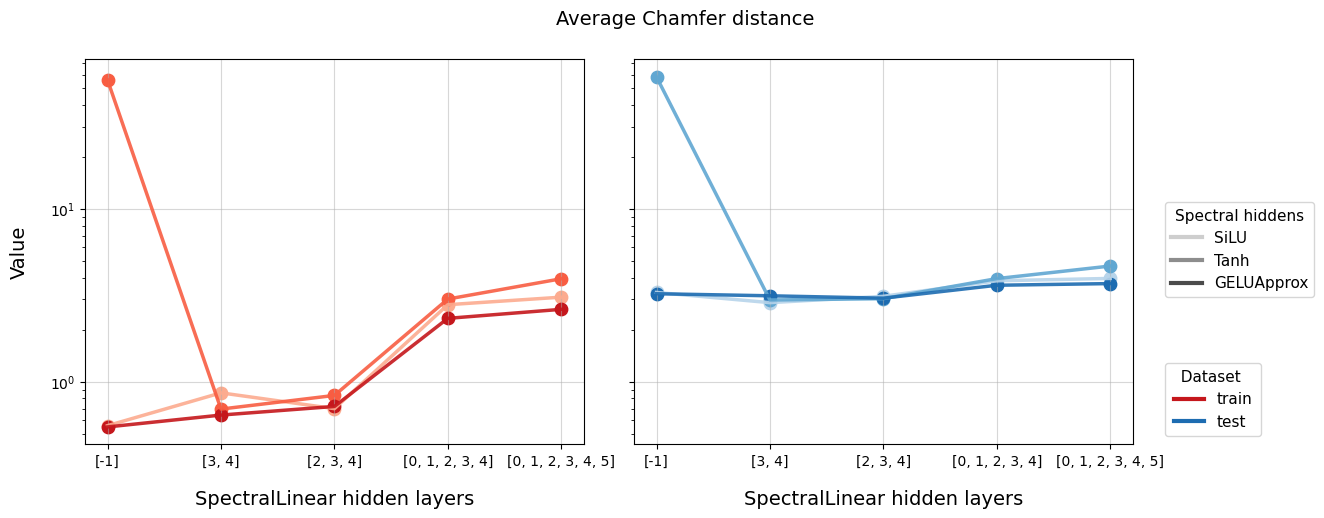

In [127]:
metric = "Chamfer"

save_fname = save_dir / f"{experiment_name}-avg{metric}-trainVStest.svg"

df_train = assign_train_dataset[metric]
df_test = assign_test_dataset[metric]

# ------------------------------
# setup things for legend and x axis labels
# ------------------------------
legend_colum, x_axis_column = add_column_2, add_column_1
# legend_tags = sorted(df_train[legend_colum].unique())
legend_tags = sorted( df_train[legend_colum].unique(), key= lambda x: len(x), reverse=False )

x_label = "SpectralLinear hidden layers" # r"$\lambda_{reg}$"

# reorder x axis if labels are categorical
df_train[x_axis_column] = pd.Categorical(
    df_train[x_axis_column],
    categories=sorted(df_train[x_axis_column].unique(), key=lambda x: len(x)),
    ordered=True
)
df_train = df_train.sort_values(add_column_1)

df_test[x_axis_column] = pd.Categorical(
    df_test[x_axis_column],
    categories=sorted(df_test[x_axis_column].unique(), key=lambda x: len(x)),
    ordered=True
)
df_test = df_test.sort_values(add_column_1)


# Colors for actual plots
cmap_tr = plt.get_cmap("Reds")
colors_tr = [cmap_tr(i / len(legend_tags) * 0.7 + 0.3 ) for i in range(len(legend_tags))]
cmap_te = plt.get_cmap("Blues")
colors_te = [cmap_te(i / len(legend_tags) * 0.7 + 0.3 ) for i in range(len(legend_tags))]

# Grayscale for batch size legend
cmap_gray = plt.get_cmap("Greys")
gray_colors = [cmap_gray(i / len(legend_tags) * 0.7 + 0.3) for i in range(len(legend_tags))]

fontsize = 14
fig, axs = plt.subplots(1, 2, figsize=(16, 5), sharey=True)  # side by side, shared y axis


# ------------------------------
# Plot Train
# ------------------------------
ax = axs[0]
for i, tag in enumerate(legend_tags):
    subset = df_train[df_train[legend_colum] == tag]
    ax.plot(subset[x_axis_column], subset['mean'], c=colors_tr[i], linewidth=2.5, alpha=0.9)
    ax.scatter(subset[x_axis_column], subset['mean'], color=colors_tr[i], s=80)
#ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(x_label, fontsize=fontsize, labelpad=15)
ax.set_ylabel("Value", fontsize=fontsize, labelpad=15)
ax.set_title("", fontsize=fontsize)
ax.grid(True, which='major', linestyle='-', alpha=0.5)
ax.tick_params(axis='both', which='major', labelsize=fontsize-4)

# ------------------------------
# Plot Test
# ------------------------------
ax = axs[1]
for i, tag in enumerate(legend_tags):
    subset = df_test[df_test[legend_colum] == tag]
    ax.plot(subset[x_axis_column], subset['mean'], c=colors_te[i], linewidth=2.5, alpha=0.9)
    ax.scatter(subset[x_axis_column], subset['mean'], color=colors_te[i], s=80)
# ax.set_xscale('log')
ax.set_xlabel(x_label, fontsize=fontsize, labelpad=15) # r"$\lambda_{reg}$"
ax.set_title("", fontsize=fontsize)
ax.grid(True, which='major', linestyle='-', alpha=0.5)
ax.tick_params(axis='both', which='major', labelsize=fontsize-4)

plt.suptitle(f"Average {metric} distance", fontsize=fontsize)

# ------------------------------
# Shared batch size legend (grayscale)
# ------------------------------
legend_handles = [
    Line2D([0], [0], color=gray_colors[i], linewidth=3, label=tag) #f"{tag:.0e}")
    for i, tag in enumerate(legend_tags)
]

which_shapes_handles = [ 
    Line2D([0], [0], color=colors_tr[-1], linewidth=3, label="train"),
    Line2D([0], [0], color=colors_te[-1], linewidth=3, label="test")
]
                        

# Shrink subplots to make room on the right
fig.subplots_adjust(right=0.78, wspace=0.1)  # the subplots will fit in left 78% of figure width

# Place legend to the right of plots
fig.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(0.8, 0.5),  # x, y in figure fraction coordinates
    fontsize=11,
    title="Spectral hiddens", #r"$\alpha$",
    title_fontsize=11,
    borderaxespad=0
)

# Second legend: train/test (colors)
fig.legend(
    handles=which_shapes_handles,
    loc='center left',
    bbox_to_anchor=(0.8, 0.2),
    fontsize=11,
    title="  Dataset   ",
    title_fontsize=11,
    borderaxespad=0
)

plt.savefig(save_fname, dpi=300, transparent=True)

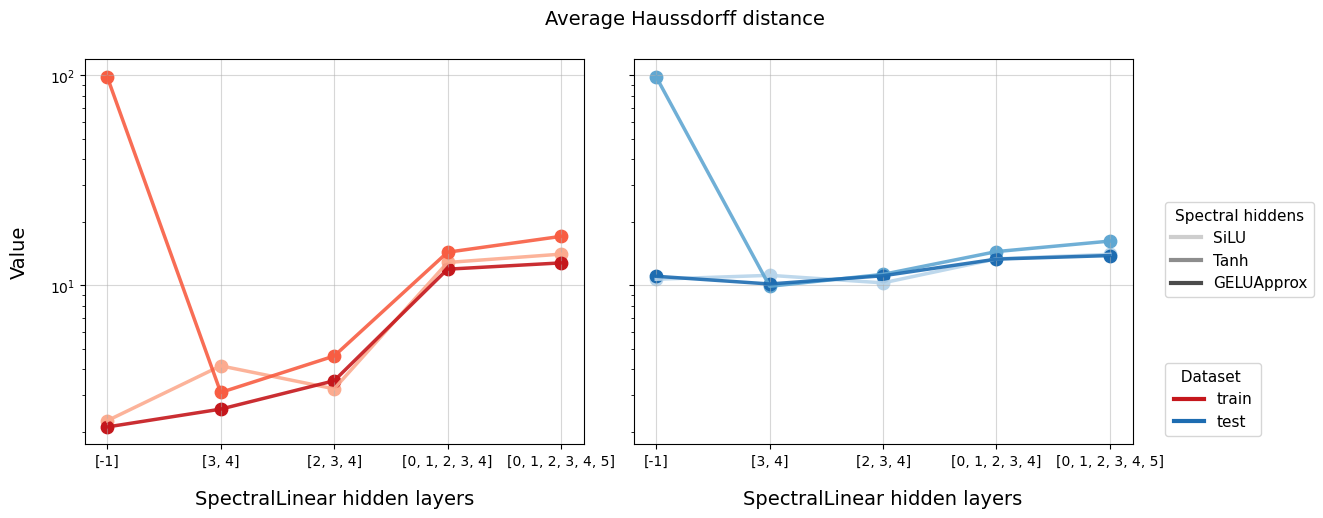

In [128]:
metric = "Haussdorff"

save_fname = save_dir / f"{experiment_name}-avg{metric}-trainVStest.svg"

df_train = assign_train_dataset[metric]
df_test = assign_test_dataset[metric]

# ------------------------------
# setup things for legend and x axis labels
# ------------------------------
legend_colum, x_axis_column = add_column_2, add_column_1
# legend_tags = sorted(df_train[legend_colum].unique())
legend_tags = sorted( df_train[legend_colum].unique(), key= lambda x: len(x), reverse=False )

x_label = "SpectralLinear hidden layers" # r"$\lambda_{reg}$"

# reorder x axis if labels are categorical
df_train[x_axis_column] = pd.Categorical(
    df_train[x_axis_column],
    categories=sorted(df_train[x_axis_column].unique(), key=lambda x: len(x)),
    ordered=True
)
df_train = df_train.sort_values(add_column_1)

df_test[x_axis_column] = pd.Categorical(
    df_test[x_axis_column],
    categories=sorted(df_test[x_axis_column].unique(), key=lambda x: len(x)),
    ordered=True
)
df_test = df_test.sort_values(add_column_1)


# Colors for actual plots
cmap_tr = plt.get_cmap("Reds")
colors_tr = [cmap_tr(i / len(legend_tags) * 0.7 + 0.3 ) for i in range(len(legend_tags))]
cmap_te = plt.get_cmap("Blues")
colors_te = [cmap_te(i / len(legend_tags) * 0.7 + 0.3 ) for i in range(len(legend_tags))]

# Grayscale for batch size legend
cmap_gray = plt.get_cmap("Greys")
gray_colors = [cmap_gray(i / len(legend_tags) * 0.7 + 0.3) for i in range(len(legend_tags))]

fontsize = 14
fig, axs = plt.subplots(1, 2, figsize=(16, 5), sharey=True)  # side by side, shared y axis


# ------------------------------
# Plot Train
# ------------------------------
ax = axs[0]
for i, tag in enumerate(legend_tags):
    subset = df_train[df_train[legend_colum] == tag]
    ax.plot(subset[x_axis_column], subset['mean'], c=colors_tr[i], linewidth=2.5, alpha=0.9)
    ax.scatter(subset[x_axis_column], subset['mean'], color=colors_tr[i], s=80)
#ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(x_label, fontsize=fontsize, labelpad=15)
ax.set_ylabel("Value", fontsize=fontsize, labelpad=15)
ax.set_title("", fontsize=fontsize)
ax.grid(True, which='major', linestyle='-', alpha=0.5)
ax.tick_params(axis='both', which='major', labelsize=fontsize-4)

# ------------------------------
# Plot Test
# ------------------------------
ax = axs[1]
for i, tag in enumerate(legend_tags):
    subset = df_test[df_test[legend_colum] == tag]
    ax.plot(subset[x_axis_column], subset['mean'], c=colors_te[i], linewidth=2.5, alpha=0.9)
    ax.scatter(subset[x_axis_column], subset['mean'], color=colors_te[i], s=80)
# ax.set_xscale('log')
ax.set_xlabel(x_label, fontsize=fontsize, labelpad=15) # r"$\lambda_{reg}$"
ax.set_title("", fontsize=fontsize)
ax.grid(True, which='major', linestyle='-', alpha=0.5)
ax.tick_params(axis='both', which='major', labelsize=fontsize-4)

plt.suptitle(f"Average {metric} distance", fontsize=fontsize)

# ------------------------------
# Shared batch size legend (grayscale)
# ------------------------------
legend_handles = [
    Line2D([0], [0], color=gray_colors[i], linewidth=3, label=tag) #f"{tag:.0e}")
    for i, tag in enumerate(legend_tags)
]

which_shapes_handles = [ 
    Line2D([0], [0], color=colors_tr[-1], linewidth=3, label="train"),
    Line2D([0], [0], color=colors_te[-1], linewidth=3, label="test")
]
                        

# Shrink subplots to make room on the right
fig.subplots_adjust(right=0.78, wspace=0.1)  # the subplots will fit in left 78% of figure width

# Place legend to the right of plots
fig.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(0.8, 0.5),  # x, y in figure fraction coordinates
    fontsize=11,
    title="Spectral hiddens", #r"$\alpha$",
    title_fontsize=11,
    borderaxespad=0
)

# Second legend: train/test (colors)
fig.legend(
    handles=which_shapes_handles,
    loc='center left',
    bbox_to_anchor=(0.8, 0.2),
    fontsize=11,
    title="  Dataset   ",
    title_fontsize=11,
    borderaxespad=0
)

plt.savefig(save_fname, dpi=300, transparent=True)

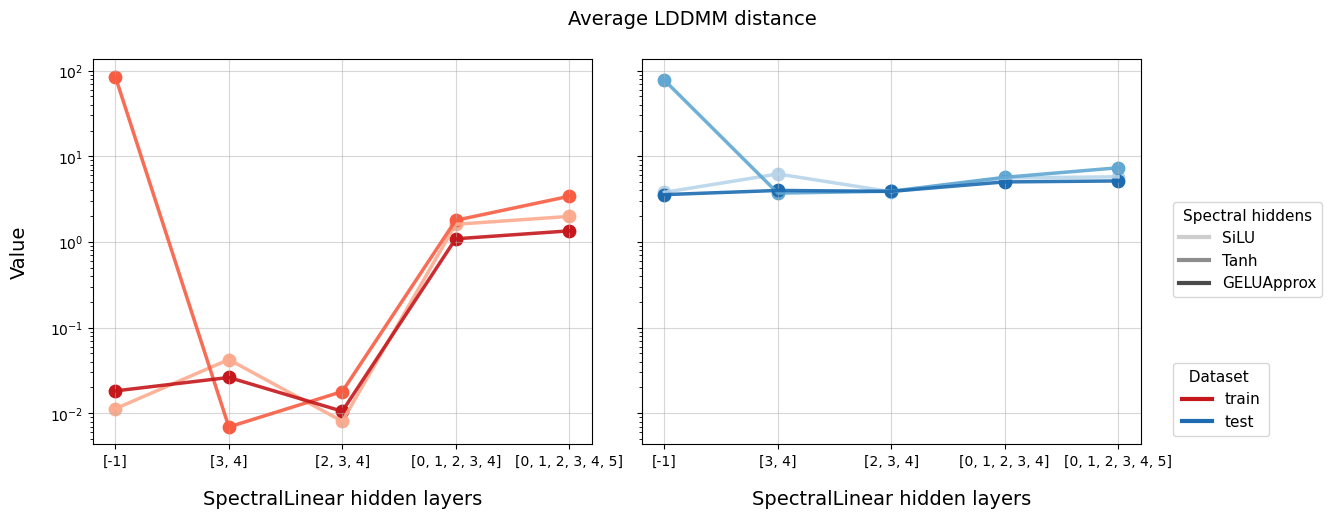

In [129]:
metric = "LDDMM"

save_fname = save_dir / f"{experiment_name}-avg{metric}-trainVStest.svg"

df_train = assign_train_dataset[metric]
df_test = assign_test_dataset[metric]

# ------------------------------
# setup things for legend and x axis labels
# ------------------------------
legend_colum, x_axis_column = add_column_2, add_column_1
# legend_tags = sorted(df_train[legend_colum].unique())
legend_tags = sorted( df_train[legend_colum].unique(), key= lambda x: len(x), reverse=False )

x_label = "SpectralLinear hidden layers" # r"$\lambda_{reg}$"

# reorder x axis if labels are categorical
df_train[x_axis_column] = pd.Categorical(
    df_train[x_axis_column],
    categories=sorted(df_train[x_axis_column].unique(), key=lambda x: len(x)),
    ordered=True
)
df_train = df_train.sort_values(add_column_1)

df_test[x_axis_column] = pd.Categorical(
    df_test[x_axis_column],
    categories=sorted(df_test[x_axis_column].unique(), key=lambda x: len(x)),
    ordered=True
)
df_test = df_test.sort_values(add_column_1)


# Colors for actual plots
cmap_tr = plt.get_cmap("Reds")
colors_tr = [cmap_tr(i / len(legend_tags) * 0.7 + 0.3 ) for i in range(len(legend_tags))]
cmap_te = plt.get_cmap("Blues")
colors_te = [cmap_te(i / len(legend_tags) * 0.7 + 0.3 ) for i in range(len(legend_tags))]

# Grayscale for batch size legend
cmap_gray = plt.get_cmap("Greys")
gray_colors = [cmap_gray(i / len(legend_tags) * 0.7 + 0.3) for i in range(len(legend_tags))]

fontsize = 14
fig, axs = plt.subplots(1, 2, figsize=(16, 5), sharey=True)  # side by side, shared y axis


# ------------------------------
# Plot Train
# ------------------------------
ax = axs[0]
for i, tag in enumerate(legend_tags):
    subset = df_train[df_train[legend_colum] == tag]
    ax.plot(subset[x_axis_column], subset['mean'], c=colors_tr[i], linewidth=2.5, alpha=0.9)
    ax.scatter(subset[x_axis_column], subset['mean'], color=colors_tr[i], s=80)
#ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(x_label, fontsize=fontsize, labelpad=15)
ax.set_ylabel("Value", fontsize=fontsize, labelpad=15)
ax.set_title("", fontsize=fontsize)
ax.grid(True, which='major', linestyle='-', alpha=0.5)
ax.tick_params(axis='both', which='major', labelsize=fontsize-4)

# ------------------------------
# Plot Test
# ------------------------------
ax = axs[1]
for i, tag in enumerate(legend_tags):
    subset = df_test[df_test[legend_colum] == tag]
    ax.plot(subset[x_axis_column], subset['mean'], c=colors_te[i], linewidth=2.5, alpha=0.9)
    ax.scatter(subset[x_axis_column], subset['mean'], color=colors_te[i], s=80)
# ax.set_xscale('log')
ax.set_xlabel(x_label, fontsize=fontsize, labelpad=15) # r"$\lambda_{reg}$"
ax.set_title("", fontsize=fontsize)
ax.grid(True, which='major', linestyle='-', alpha=0.5)
ax.tick_params(axis='both', which='major', labelsize=fontsize-4)

plt.suptitle(f"Average {metric} distance", fontsize=fontsize)

# ------------------------------
# Shared batch size legend (grayscale)
# ------------------------------
legend_handles = [
    Line2D([0], [0], color=gray_colors[i], linewidth=3, label=tag) #f"{tag:.0e}")
    for i, tag in enumerate(legend_tags)
]

which_shapes_handles = [ 
    Line2D([0], [0], color=colors_tr[-1], linewidth=3, label="train"),
    Line2D([0], [0], color=colors_te[-1], linewidth=3, label="test")
]
                        

# Shrink subplots to make room on the right
fig.subplots_adjust(right=0.78, wspace=0.1)  # the subplots will fit in left 78% of figure width

# Place legend to the right of plots
fig.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(0.8, 0.5),  # x, y in figure fraction coordinates
    fontsize=11,
    title="Spectral hiddens", #r"$\alpha$",
    title_fontsize=11,
    borderaxespad=0
)

# Second legend: train/test (colors)
fig.legend(
    handles=which_shapes_handles,
    loc='center left',
    bbox_to_anchor=(0.8, 0.2),
    fontsize=11,
    title="  Dataset   ",
    title_fontsize=11,
    borderaxespad=0
)

plt.savefig(save_fname, dpi=300, transparent=True)